# Imports 

In [1]:
import pandas as pd
import os
import re
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import numpy as np
import matplotlib.patches as mpatches

# Functions

# Datasets

In [2]:
path = "../../Data_Processing/outputs"

In [3]:
df = pd.concat(
    [
        pd.read_pickle(os.path.join(path, file))
        for file in os.listdir(path)
        if "df_banks_part_" in file
    ],
    axis=0,
).reset_index(drop=True)

In [4]:
df.head()

,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,RECOVERIES_FARMERS_FRY9C,RECOVERIES_COMMERCE_INDUSTRY_FRY9C,RECOVERIES_HOUSEHOLDS_FRY9C,RECOVERIES_FOREIGN_GOV_FRY9C,RECOVERIES_LEASE_FINANCING_FRY9C,RATIO_CAPITAL_CONSERVATION_BUFFER_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C
0,1020201,UNITED STATES,HSBC USA INC.,20250630,0.0,0.0,432366.0,0.0,0.0,449067.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1020395,UNITED STATES,SOUTHERN NATIONAL CORPORATION,20250630,0.0,4913.0,0.0,0.0,6956.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1020582,UNITED STATES,WOODTRUST FINANCIAL CORPORATION,20250630,0.0,3889.0,0.0,0.0,12123.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1020676,UNITED STATES,AMALGAMATED INVESTMENTS COMPANY,20250630,0.0,1237.0,0.0,0.0,4954.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1020854,UNITED STATES,"BANK MANAGEMENT, INC.",20250630,0.0,0.0,0.0,0.0,3799.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_cols = pd.Series(df.columns)

In [6]:
#target variable: 
#   reduction in revenue
#   reduction in net income
#   reduction in assets

# Adjust columns

## Metadata

In [12]:
df['year'] = df['quarter'].str[:4].astype(int)
df['month'] = df['quarter'].str[4:6].astype(int)
df['nr_quarter'] = ((df['month'] - 1) // 3) + 1

## Cummulative to per quarter features

Based on the reviewed documentation, we identified that the reported income statement figures (e.g., revenue, costs, profit) represent year-to-date values for each fiscal year. This means that each quarter’s figures are cumulative for that year, resetting at the beginning of the first quarter.

In contrast, the balance sheet figures (e.g., assets, liabilities, equity) reflect the position at the end of each quarter and do not reset at the start of the year.

Therefore, for income statement data, we chose to estimate the quarterly contribution to eliminate the seasonality effect caused by the reset in the first quarter of each year.


Sources:
- FR Y -9c 
    - financial statement: https://www.federalreserve.gov/reportforms/forms/FR_Y-9C20180930_f.pdf
    - detail on financial statement rubrics: https://www.federalreserve.gov/apps/reportingforms/Download/DownloadAttachment?guid=d036ea09-75d3-4f2f-8fe3-0f43c76d2f70

- FR_Y-9LP (Parent Company Only Financial Statements for Large Bank Holding Companies): 
    - financial statement: https://www.federalreserve.gov/apps/reportingforms/Download/DownloadAttachment?guid=e56cd829-8369-4263-96ca-4de4e12ce585#:~:text=03/2024-,For%20Federal%20Reserve%20Bank%20Use%20Only,for%20investments%20in%20equity%20securities.
    - detail on financial statement rubrics: https://www.federalreserve.gov/reportforms/forms/FR_Y-9LP20220705_i.pdf 

- FR Y-9SP (Parent Company Only Financial Statements for Small Holding Companies) - only reports data semi-annually 
    - financial statement: https://www.federalreserve.gov/apps/reportingforms/Download/DownloadAttachment?guid=9df5bb23-468c-4407-a874-7beaba03b930
    - detail on financial statement rubrics: https://www.federalreserve.gov/apps/reportingforms/Download/DownloadAttachment?guid=05505b4f-780d-49e0-a123-59e7cbf29afb


In [13]:
df_cols = pd.Series(df.columns)

In [14]:
df_cols.str.split('_').str[0].value_counts()
#To identify the income 

ASSETS        48
CHARGED        6
TOTAL          6
RECOVERIES     6
RATIO          5
NET            5
LOANS          3
REVENUE        3
EBT            3
CAPITAL        3
id             1
quarter        1
country        1
legal          1
year           1
month          1
nr             1
Name: count, dtype: int64

In [15]:
list_cols_cummulative = df_cols[df_cols.str.startswith(('REVENUE', 'NET_INCOME','CHARGED','RECOVERIES','LOANS','REVENUE','EBT'))].unique()
#CHECK OTHER COLS

In [16]:
def calc_per_quarter_value(list_report_col, df):
    # Sort to ensure correct order for diff within each id/year
    df = df.sort_values(['id', 'year', 'nr_quarter'])
    
    for report_col in list_report_col:
        # Compute actuals only for Q2–Q4; keep Q1 as cumulative
        actual = df.groupby(['id', 'year'])[report_col].diff()
        df[f'{report_col}_CUMMULATIVE'] = df[report_col]
        df[report_col] = actual.where(df['nr_quarter'] > 1, df[report_col]).fillna(0)
    return df

In [17]:
df_new = calc_per_quarter_value(list_report_col=list_cols_cummulative, df=df)
df_new.head()

,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,CHARGED_OFF_COMMERCE_INDUSTRY_FRY9C_CUMMULATIVE,CHARGED_OFF_HOUSEHOLDS_FRY9C_CUMMULATIVE,CHARGED_OFF_FOREIGN_GOV_FRY9C_CUMMULATIVE,CHARGED_OFF_LEASE_FINANCING_FRY9C_CUMMULATIVE,RECOVERIES_REAL_ESTATE_FRY9C_CUMMULATIVE,RECOVERIES_FARMERS_FRY9C_CUMMULATIVE,RECOVERIES_COMMERCE_INDUSTRY_FRY9C_CUMMULATIVE,RECOVERIES_HOUSEHOLDS_FRY9C_CUMMULATIVE,RECOVERIES_FOREIGN_GOV_FRY9C_CUMMULATIVE,RECOVERIES_LEASE_FINANCING_FRY9C_CUMMULATIVE
314775,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000331,85127.0,0.0,10360.0,11016.0,0.0,11016.0,...,269.0,0.0,0.0,0.0,1.0,78.0,62.0,0.0,0.0,0.0
308921,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000630,91546.0,0.0,13944.0,11063.0,0.0,11063.0,...,583.0,0.0,0.0,0.0,6.0,130.0,167.0,0.0,0.0,0.0
306773,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000930,95458.0,0.0,7320.0,11675.0,0.0,11675.0,...,2661.0,0.0,0.0,0.0,5.0,144.0,257.0,0.0,0.0,0.0
300917,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20001231,96257.0,0.0,21342.0,12027.0,0.0,12027.0,...,3273.0,0.0,0.0,0.0,7.0,168.0,320.0,0.0,0.0,0.0
298721,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20010331,94175.0,0.0,13907.0,11174.0,0.0,11174.0,...,2142.0,82.0,0.0,0.0,9.0,47.0,164.0,9.0,0.0,0.0


## Consolidate per report columns into a single one

In [19]:
df_cols_all = pd.DataFrame((df_cols.str.split('_').str[:-1].apply('_'.join), df_cols.str.split('_').str[-1])).T

In [55]:
df_9c_aux = df.loc[:,[col for col in df_new.columns if col.upper()!=col or col.endswith('_FRY9C')]]
df_splp_aux = df.loc[:,[col for col in df_new.columns if col.upper()!=col or col.endswith('_FRY9SP') or col.endswith('_FRY9LP')]]

In [56]:

# Identify columns that start with TOTAL_ or REVENUE
cols_to_check = [col for col in df_9c_aux.columns if col.startswith('TOTAL_') or col.startswith('REVENUE')]

# Group by 'id' and check if all values in these columns are zero for each group
group_check = df_9c_aux.groupby('id')[cols_to_check].apply(lambda x: (x == 0).all().all())

# IDs that always have zeros across all rows
ids_never_9c = group_check[group_check].index.tolist()

# IDs that have at least one non-zero value
ids_at_least_once9c = group_check[~group_check].index.tolist()

print("IDs that always have zeros:", ids_never_9c)
print("IDs with at least one non-zero:", ids_at_least_once9c)


IDs that always have zeros: ['1020322', '1020377', '1020443', '1020591', '1020630', '1020667', '1020751', '1020836', '1020854', '1020863', '1021132', '1021655', '1021767', '1021936', '1021981', '1022063', '1022139', '1022278', '1022625', '1022858', '1023145', '1023172', '1023341', '1023387', '1029932', '1030004', '1030022', '1030880', '1031373', '1031515', '1031524', '1050057', '1050066', '1050093', '1050150', '1050178', '1050226', '1050495', '1050619', '1050628', '1050730', '1050749', '1050776', '1050794', '1050806', '1050824', '1050833', '1050851', '1050879', '1051009', '1051045', '1051054', '1051063', '1051072', '1051175', '1051193', '1051223', '1051269', '1051317', '1051353', '1051362', '1051371', '1051380', '1051399', '1051401', '1051410', '1051429', '1051504', '1051568', '1051625', '1051670', '1051689', '1051698', '1051728', '1051849', '1051924', '1051951', '1052293', '1052314', '1052332', '1052350', '1052369', '1052387', '1052417', '1052640', '1052789', '1052846', '1052882', '10

In [57]:

# Identify columns that start with TOTAL_ or REVENUE
cols_to_check_splp = [col for col in df_splp_aux.columns if col.startswith('TOTAL_') or col.startswith('REVENUE')]

# Group by 'id' and check if all values in these columns are zero for each group
group_check = df_splp_aux.groupby('id')[cols_to_check_splp].apply(lambda x: (x == 0).all().all())

# IDs that always have zeros across all rows
ids_never_splp = group_check[group_check].index.tolist()

# IDs that have at least one non-zero value
ids_at_least_oncessplp = group_check[~group_check].index.tolist()

print("IDs that always have zeros:", ids_never_splp)
print("IDs with at least one non-zero:", ids_at_least_oncessplp)


IDs that always have zeros: ['1126103', '1143249', '1143258', '2727271', '3943386', '3948420', '5081947', '5189450']
IDs with at least one non-zero: ['1020180', '1020201', '1020322', '1020340', '1020377', '1020395', '1020443', '1020582', '1020591', '1020630', '1020667', '1020676', '1020751', '1020836', '1020854', '1020863', '1020902', '1020920', '1021132', '1021570', '1021628', '1021655', '1021682', '1021767', '1021879', '1021936', '1021981', '1022063', '1022139', '1022166', '1022269', '1022278', '1022353', '1022625', '1022661', '1022764', '1022858', '1022924', '1022997', '1023145', '1023154', '1023172', '1023220', '1023239', '1023341', '1023387', '1024058', '1025309', '1025541', '1025608', '1025662', '1026632', '1026801', '1027004', '1027518', '1027602', '1027947', '1027992', '1028038', '1028412', '1028533', '1029071', '1029213', '1029222', '1029259', '1029286', '1029295', '1029334', '1029428', '1029464', '1029482', '1029576', '1029884', '1029893', '1029932', '1030004', '1030022', '10

In [108]:
df_9c = df_new[df_new['id'].isin(ids_at_least_once9c)].loc[:,[col for col in df_new.columns if col.upper()!=col or col.endswith('_FRY9C')]]
df_9c.columns = [col.split('_FRY9C')[0] for col in df_9c.columns]
df_9c['report_type'] = 'FRY9C'

In [81]:
cols_to_check_sp = [col for col in df_splp_aux.columns if (col.startswith('TOTAL_') or col.startswith('REVENUE') or col.startswith('NET_INCOME')) and (col.endswith('_FRY9SP'))]
cols_to_check_lp = [col for col in df_splp_aux.columns if (col.startswith('TOTAL_') or col.startswith('REVENUE') or col.startswith('NET_INCOME')) and (col.endswith('_FRY9LP'))]

In [82]:
# df_lp_aux = df_new.loc[:,cols_to_check_lp+['id','quarter']].groupby(['id','quarter']).sum().sum(axis=1)
df_lp_aux = df_new.loc[:,cols_to_check_lp+['id','quarter']].groupby(['id','quarter']).sum().stack()
idxs_lp = df_lp_aux[df_lp_aux!=0].reset_index().loc[:,['id','quarter']].apply(tuple,axis=1).tolist()

In [83]:
# df_sp_aux = df_new.loc[:,cols_to_check_sp+['id','quarter']].groupby(['id','quarter']).sum().sum(axis=1)
df_sp_aux = df_new.loc[:,cols_to_check_sp+['id','quarter']].groupby(['id','quarter']).sum().stack()
idxs_sp = df_sp_aux[df_sp_aux!=0].reset_index().loc[:,['id','quarter']].apply(tuple,axis=1).tolist()

In [84]:
df_splp = df_new.copy()

In [85]:
df_splp_aux = df_new.copy().loc[:,[col for col in df_new.columns if col.upper()!=col or col.endswith('_FRY9SP') or col.endswith('_FRY9LP')]]


# Convert idxs_sp and idxs_lp to sets of tuples for fast lookup
sp_set = set(map(tuple, idxs_sp))
lp_set = set(map(tuple, idxs_lp))

# Define a function to assign report_type
def get_report_type(row):
    pair = (row['id'], row['quarter'])
    if pair in sp_set and pair in lp_set:
        return 'FRY9SP_FRY9LP'
    elif pair in sp_set:
        return 'FRY9SP'
    elif pair in lp_set:
        return 'FRY9LP'
    else:
        return 'FRY9SP_FRY9LP'  # Default if not in either set

# Apply the function to create the new column
df_splp_aux['report_type'] = df_splp_aux.apply(get_report_type, axis=1)

In [86]:
df_sp_aux = df_splp_aux[df_splp_aux['report_type']=='FRY9SP'].loc[:,[col for col in df_splp_aux.columns if col.upper()!=col or
                                                                     col.endswith('_FRY9SP')]]

df_sp_aux.columns = [col.split('_FRY9SP')[0] for col in df_sp_aux.columns if col.upper()!=col or
                                                                     col.endswith('_FRY9SP')]

In [87]:
df_lp_aux = df_splp_aux[df_splp_aux['report_type']=='FRY9LP'].loc[:,[col for col in df_splp_aux.columns if col.upper()!=col or
                                                                     col.endswith('_FRY9LP')]]

df_lp_aux.columns = [col.split('_FRY9LP')[0] for col in df_lp_aux.columns if col.upper()!=col or
                                                                     col.endswith('_FRY9LP')]

In [88]:
df_splp_other_aux_ = df_splp_aux[df_splp_aux['report_type']=='FRY9SP_FRY9LP']

# df_splp_other_aux_.columns = [col.split('_FRY9LP')[0] for col in df_splp_other_aux_.columns if col.upper()!=col or
#                                                                      col.endswith('_FRY9LP')]

In [89]:
##check that institutiosn institutions were not mapped as SP or LP have 0 or nulls values in the other columns
aux_ = df_splp_other_aux_.loc[:,[col for col in df_splp_other_aux_ if col.upper() == col]]
(aux_.isna() | (aux_ == 0)).all().all()

np.False_

In [90]:
df_splp_other_aux_lp_ = df_splp_other_aux_.loc[:,[col for col in df_splp_aux.columns if col.endswith('_FRY9LP')]]
df_splp_other_aux_lp_.columns = [col.split('_FRY9LP')[0] for col in df_splp_other_aux_lp_.columns if col.upper()!=col or
                                                                     col.endswith('_FRY9LP')]

In [91]:
df_splp_other_aux_sp_ = df_splp_other_aux_.loc[:,[col for col in df_splp_aux.columns if col.endswith('_FRY9SP')]]
df_splp_other_aux_sp_.columns = [col.split('_FRY9SP')[0] for col in df_splp_other_aux_sp_.columns if col.upper()!=col or
                                                                     col.endswith('_FRY9SP')]

In [92]:
df_splp_other_ = (df_splp_other_aux_sp_ + df_splp_other_aux_lp_).where(
    df_splp_other_aux_sp_.notna() & df_splp_other_aux_lp_.notna()
)


In [93]:
df_splp_other_.loc[:,[col for col in df_splp_other_aux_.columns if col.upper() !=col]] = df_splp_other_aux_.loc[:,[col for col in df_splp_other_aux_.columns if col.upper() !=col]]

In [94]:
df_splp_other_aux_.loc[:,[col for col in df_splp_other_aux_.columns if col.upper() !=col]]

,id,country,legal_name,quarter,year,month,nr_quarter,report_type
54847,1020676,UNITED STATES,AMALGAMATED INVESTMENTS COMPANY,20181231,2018,12,4,FRY9SP_FRY9LP
274266,1020920,UNITED STATES,CENTRAL TRUST COMPANY,20020930,2002,9,3,FRY9SP_FRY9LP
253356,1021570,UNITED STATES,"VIKING CORPORATION, THE",20031231,2003,12,4,FRY9SP_FRY9LP
306784,1021981,UNITED STATES,"BUFFALO NATIONAL BANCSHARES, INC.",20000930,2000,9,3,FRY9SP_FRY9LP
290629,1022166,UNITED STATES,FIRST CARTHAGE CORPORATION,20010930,2001,9,3,FRY9SP_FRY9LP
...,...,...,...,...,...,...,...,...
40323,5213690,UNITED STATES,"DIAMOND HTH STOCK COMPANY GP, LLC",20201231,2020,12,4,FRY9SP_FRY9LP
21358,5213690,UNITED STATES,"DIAMOND HTH STOCK COMPANY GP, LLC",20230331,2023,3,1,FRY9SP_FRY9LP
20709,5213690,UNITED STATES,"DIAMOND HTH STOCK COMPANY GP, LLC",20230630,2023,6,2,FRY9SP_FRY9LP
17024,5213690,UNITED STATES,"DIAMOND HTH STOCK COMPANY GP, LLC",20230930,2023,9,3,FRY9SP_FRY9LP


In [95]:
df_parent_company_aux = pd.concat([df_sp_aux, df_lp_aux, df_splp_other_],axis=0).reset_index(drop=True)
df_parent_company = df_parent_company_aux[
    sorted(df_parent_company_aux.columns, key=lambda c: (not c[0].islower(), c.lower(), c))
].sort_values(by=['id','quarter'])

In [96]:
df_parent_company

,country,id,legal_name,month,nr_quarter,quarter,report_type,year,ASSETS_BALANCES_BANKS,ASSETS_BALANCES_HOLDINGS,...,ASSETS_SECURITIES_USTREASURY,ASSETS_TOTALASSETS,CAPITAL_TIER12,EBT,LOANS_LOSS_PROVISIONS,NET_INCOME,NET_INCOME_BEF_UND_RUB,REVENUE,TOTAL_ASSETS,TOTAL_EQUITY
190702,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,3,1,20000331,FRY9LP,2000,0.0,0.0,...,0.0,429604.0,7663.0,7874.0,0.0,11016.0,8410.0,10360.0,429604.0,317077.0
190703,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,6,2,20000630,FRY9LP,2000,0.0,0.0,...,0.0,428612.0,7608.0,10992.0,0.0,11063.0,11636.0,13944.0,428612.0,326574.0
190704,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,9,3,20000930,FRY9LP,2000,0.0,0.0,...,0.0,434796.0,7517.0,4542.0,0.0,11675.0,5213.0,7320.0,434796.0,338388.0
190705,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,12,4,20001231,FRY9LP,2000,0.0,0.0,...,0.0,439731.0,7435.0,18819.0,0.0,12027.0,19400.0,21342.0,439731.0,354039.0
190706,UNITED STATES,1020180,BREMER FINANCIAL CORPORATION,3,1,20010331,FRY9LP,2001,0.0,0.0,...,0.0,454814.0,7336.0,11232.0,0.0,11174.0,11811.0,13907.0,454814.0,362597.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190697,UNITED STATES,6006899,"WINCHESTER BANCORP, MHC",6,2,20250630,FRY9SP,2025,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,63452.0,63444.0
190698,UNITED STATES,6007421,"WINCHESTER BANCORP, INC.",6,2,20250630,FRY9SP,2025,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,115367.0,115352.0
190699,UNITED STATES,6010430,LINDSEY FAMILY TRUST,6,2,20250630,FRY9SP,2025,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,5523.0,613.0
190700,UNITED STATES,6030278,FIRST SOUTHERN NATIONAL BANCSHARES INC,6,2,20250630,FRY9SP,2025,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,138330.0,136330.0


## Target variable definition

In [183]:
df_9c.to_pickle('../../Data_Processing/df_y9c.pickle')

In [97]:
df_9c['year'] = df_9c['quarter'].str[:4].astype(int)
df_9c['month'] = df_9c['quarter'].str[4:6].astype(int)
df_9c['nr_quarter'] = ((df_9c['month'] - 1) // 3) + 1

In [105]:
df_9c_sorted = df_9c[
    sorted(df_9c.columns, key=lambda c: (not c[0].islower(), c.lower(), c))
].sort_values(by=['id','quarter'])

In [106]:
import pandas as pd

def value_x_quarters_before(df: pd.DataFrame, quarter: str, nr_quarters_before: int, value_col: str):
    """
    Returns the values x quarters before a target quarter for any given column.

    Parameters:
        df (pd.DataFrame): DataFrame with columns ['id', 'year', 'nr_quarter', ...].
        quarter (str): Target quarter YYYYMMDD.
        nr_quarters_before (int): Number of quarters to go back.
        value_col (str): Name of the column to retrieve values for.

    Returns:
        pd.DataFrame: DataFrame with columns ['id', 'year', 'nr_quarter', f'{value_col}_x_quarters_before']
    """
    
    target_year = int(quarter[:4])
    target_month = int(quarter[4:6])
    target_quarter = ((target_month - 1) // 3) + 1 

    # Compute the target quarter’s "absolute quarter number"
    target_abs_quarter = target_year * 4 + target_quarter
    
    # Compute the quarter to look for
    desired_abs_quarter = target_abs_quarter - nr_quarters_before
    
    # Convert abs_quarter back to year and quarter
    desired_year = desired_abs_quarter // 4
    desired_quarter = desired_abs_quarter % 4
    if desired_quarter == 0:
        desired_year -= 1
        desired_quarter = 4

    # Filter for desired quarter
    result = df[(df['year'] == desired_year) & (df['nr_quarter'] == desired_quarter)].copy()
    
    return result[['id', 'year', 'nr_quarter', value_col]]


In [179]:
selected_col = 'TOTAL_ASSETS'
target_quarter = '20241231'
nr_quarters_before = 8

# Get the values x quarters before
df_value_x_quarters_before = value_x_quarters_before(
    df=df_9c_sorted,
    quarter=target_quarter,
    nr_quarters_before=nr_quarters_before,
    value_col=selected_col
)


# Get target quarter values
df_target = df_9c_sorted[df_9c_sorted['quarter'] == target_quarter][['id', 'year', 'nr_quarter', selected_col]]

# Merge on 'id' so we can calculate ratio
df_merged = df_target.merge(
    df_value_x_quarters_before[['id', selected_col]],
    on='id',
    suffixes=('_target', f'_prev_{nr_quarters_before}_quarters')
)

# Calculate ratio
df_merged[f'{selected_col}_growth_{nr_quarters_before}_quarters'] = df_merged[f'{selected_col}_target'] / df_merged[f'{selected_col}_prev_{nr_quarters_before}_quarters'] - 1
df_merged[f'{selected_col}_growth_annualized'] = (
    (1 + df_merged[f'{selected_col}_growth_{nr_quarters_before}_quarters']) ** (4 / nr_quarters_before) - 1
)


In [180]:
df_filtered = df_merged[
    df_merged[f'{selected_col}_growth_annualized'].notnull() & np.isfinite(df_merged[f'{selected_col}_growth_annualized'])
]

<Axes: >

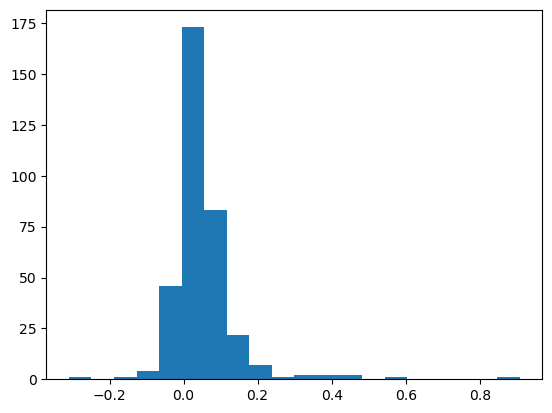

In [181]:
df_filtered[df_filtered[f'{selected_col}_target'].fillna(0)!=0].sort_values(f'{selected_col}_growth_annualized').iloc[:,-1].hist(bins=20, grid=False)

<Axes: >

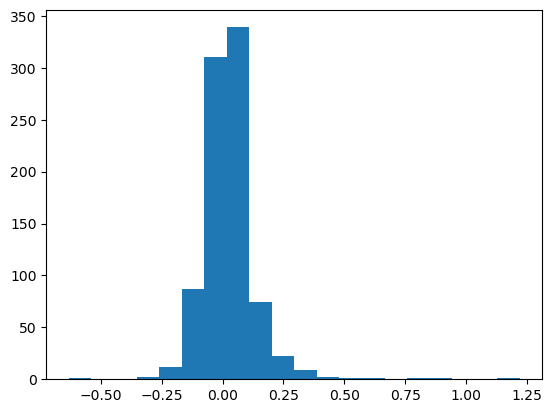

In [178]:
df_filtered[df_filtered[f'{selected_col}_target'].fillna(0)!=0].sort_values(f'{selected_col}_growth_annualized').iloc[:,-1].hist(bins=20, grid=False)

## Estimate correlations

In [ ]:
cols_to_consider = [col for col in df_new.columns if ('CUMMULATIVE' not in col) and 
                                                    (col.upper() == col)]


corr = df_new.loc[:,cols_to_consider].iloc[:, 4:].corr().stack().reset_index()
corr.columns = ['var1', 'var2', 'correlation']

# Sort variable names in each pair to ignore order
corr[['var1', 'var2']] = corr[['var1', 'var2']].apply(lambda row: sorted(row), axis=1, result_type='expand')

# Drop duplicates (since now var1-var2 and var2-var1 are the same)
corr = corr.drop_duplicates()

# Remove self-correlations
corr = corr[corr['var1'] != corr['var2']]

# Optional: filter by threshold
filtered = corr[corr['correlation'] > 0.8]


In [ ]:
corr.sort_values(by='correlation')

,var1,var2,correlation
124,ASSETS_INVESTMENT_NONBANKSUBSIDIARY_EQUITY_FRY9SP,NET_INCOME_FRY9LP,-0.318648
2195,ASSETS_INVESTMENT_BANK_SUBSIDIARY_EQUITY_FRY9SP,ASSETS_INVESTMENT_HOLDINGSUBSIDIARY_EQUITY_FRY9SP,-0.185029
104,ASSETS_CASH_FRY9SP,NET_INCOME_FRY9LP,-0.132359
118,ASSETS_INVESTMENT_BANK_SUBSIDIARY_EQUITY_FRY9SP,NET_INCOME_FRY9LP,-0.129370
134,ASSETS_OTHERASSETS_FRY9SP,NET_INCOME_FRY9LP,-0.126691
...,...,...,...
414,TOTAL_ASSETS_FRY9SP,TOTAL_EQUITY_FRY9SP,0.989986
4866,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
4795,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
4796,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,1.000000


In [ ]:
filtered.sort_values(by='correlation')

,var1,var2,correlation
2428,ASSETS_FEDERALFUNDS_RESELL_FRY9C,ASSETS_FIXEDASSETS_FRY9C,0.800185
562,ASSETS_OTHERASSETS_FRY9C,TOTAL_EQUITY_FRY9C,0.801931
4797,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,0.801949
4937,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,0.801949
1829,ASSETS_INVESTMENTS_SUBSIDIARIES_FRY9C,ASSETS_LOANSRECEIVABLES_INVESTMENT_FRY9C,0.802535
...,...,...,...
414,TOTAL_ASSETS_FRY9SP,TOTAL_EQUITY_FRY9SP,0.989986
4866,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
4795,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
504,ASSETS_TOTALASSETS_FRY9LP,TOTAL_ASSETS_FRY9LP,1.000000


In [ ]:
df.sort_values(by=['id','quarter'])


,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,RECOVERIES_FOREIGN_GOV_FRY9C,RECOVERIES_LEASE_FINANCING_FRY9C,RATIO_CAPITAL_CONSERVATION_BUFFER_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,year,month,nr_quarter
314775,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000331,85127.0,0.0,10360.0,11016.0,0.0,11016.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,3,1
308921,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000630,176673.0,0.0,24304.0,22079.0,0.0,22079.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,6,2
306773,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000930,272131.0,0.0,31624.0,33754.0,0.0,33754.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,9,3
300917,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20001231,368388.0,0.0,52966.0,45781.0,0.0,45781.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,12,4
298721,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20010331,94175.0,0.0,13907.0,11174.0,0.0,11174.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2001,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3740,6006899,UNITED STATES,"WINCHESTER BANCORP, MHC",20250630,0.0,0.0,0.0,0.0,-338.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3741,6007421,UNITED STATES,"WINCHESTER BANCORP, INC.",20250630,0.0,100.0,0.0,0.0,-615.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3742,6010430,UNITED STATES,LINDSEY FAMILY TRUST,20250630,0.0,0.0,0.0,0.0,212.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3743,6030278,UNITED STATES,FIRST SOUTHERN NATIONAL BANCSHARES INC,20250630,0.0,3000.0,0.0,0.0,11362.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
